In [1]:
# I will go ahead and import everything I think I will need here. If I come 
# across additional packages, I will import them in the appropriate code.
# Just a note, I will probably import these packages multiple times because
# it's easier than looking back to see if I imported them.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

In [2]:
# Reading the dataset
bike_df = pd.read_csv("day.csv")

<font size = "4"><strong><span style = 'color:blue'> Phase 1: Problem statement </span></strong></font>

In [3]:
# Originally, I was only looking for the impact of weather on bike usage.
# As such, I removed several columns I thought weren't important, but as
# I performed my analysis, I realized I was incorrect in thinking some of
# the columns weren't important, so I started over and this is the result
# of that.

# My problem statement now is to find the variables that most directly 
# affect bike rental and usage so that, as a transit planner, I know when
# and how to deploy resources not just for the bike rentals, but also 
# subways, buses, etc. For instance, when bike rentals are up, subway
# traffic may be down, so I'll know better where to deploy security.
print(bike_df.columns)

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')


In [4]:
bike_df = bike_df.drop('instant', axis=1)

<font size = "4"><strong><span style = 'color:blue'> Phase 2: Data processing and exploration </span></strong></font>

In [5]:
# Cleaning the data. First, I'll look for any missing values. There are none.
missing = bike_df.isnull().sum()
print(missing)

dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [6]:
# Now, I'll check for any outliers in the data. I'm only using the 'cnt' column
# because total daily count is what I care about in this project. I may come back
# later and look at registered users if that proves to be a significant variable,
# which I suspect.

# I should note that in the company for which I currently work, I spent 12 years
# managing an analytical laboratory that works with large datasets and statistical
# analysis, so I'm employing standard techniques to determine outliers. 

Q1 = bike_df['cnt'].quantile(0.25)
Q3 = bike_df['cnt'].quantile(0.75)
IQR = Q3 - Q1

print(Q1 - 1.5*IQR)
print(Q3 + 1.5*IQR)

-1054.0
10162.0


In [7]:
print(bike_df['cnt'].describe())

count     731.000000
mean     4504.348837
std      1937.211452
min        22.000000
25%      3152.000000
50%      4548.000000
75%      5956.000000
max      8714.000000
Name: cnt, dtype: float64


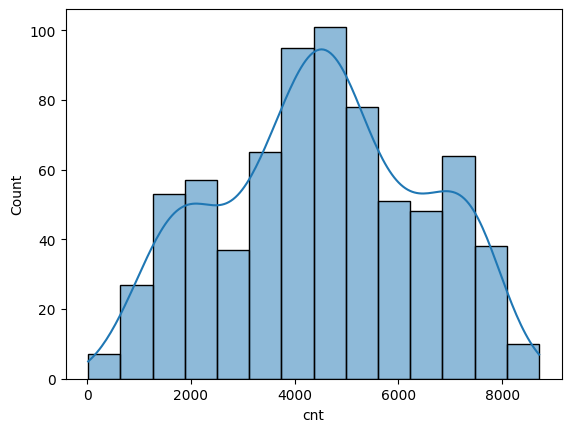

In [8]:
# Based on the data above, we do not have any outliers, but I have run a 
# histogram just to have visual confirmation of that fact. The curve looks 
# odd, but it shows no outliers.

sns.histplot(bike_df['cnt'], kde=True)
plt.show()

In [9]:
print(bike_df.columns)

Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt'],
      dtype='object')


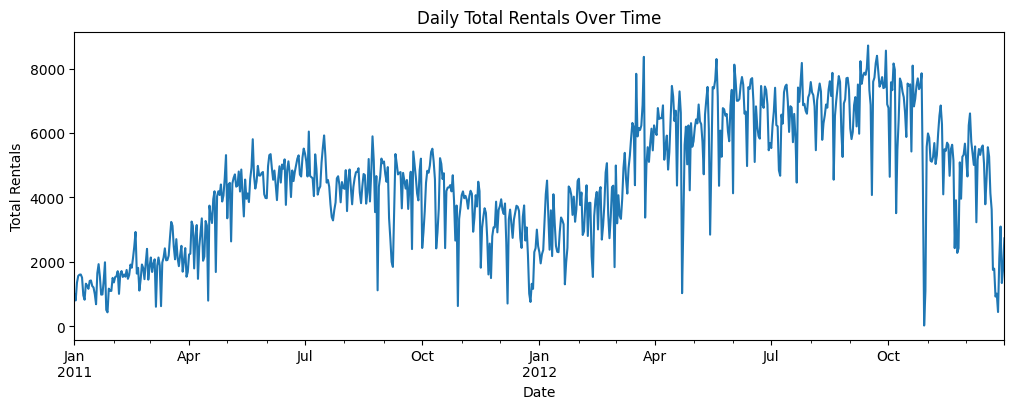

In [10]:
# I'm satisfied that the data is clean.
# I did notice something when I was looking at the dataset and now I want
# to explore the possibility that I saw something from the numbers and 
# verify it. What I saw was an increase in bike usage in the second year.

bike_df = bike_df.copy()
bike_df['dteday'] = pd.to_datetime(bike_df['dteday'])
bike_df.set_index('dteday')['cnt'].plot(figsize=(12, 4), 
                                   title="Daily Total Rentals Over Time")
plt.ylabel("Total Rentals")
plt.xlabel("Date")
plt.show()

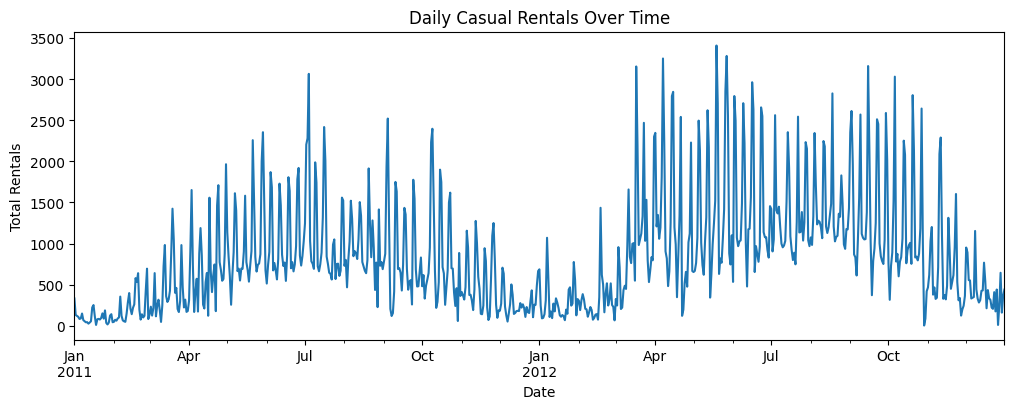

In [13]:
# As I thought, there is a significant increase in usage from 2011 to 2012.
# To see what may be causing this, I'll run a time series graph of casual users
# and registered (repeat) users.

bike_df.set_index('dteday')['casual'].plot(figsize=(12, 4), title="Daily Casual Rentals Over Time")
plt.ylabel("Total Rentals")
plt.xlabel("Date")
plt.show()

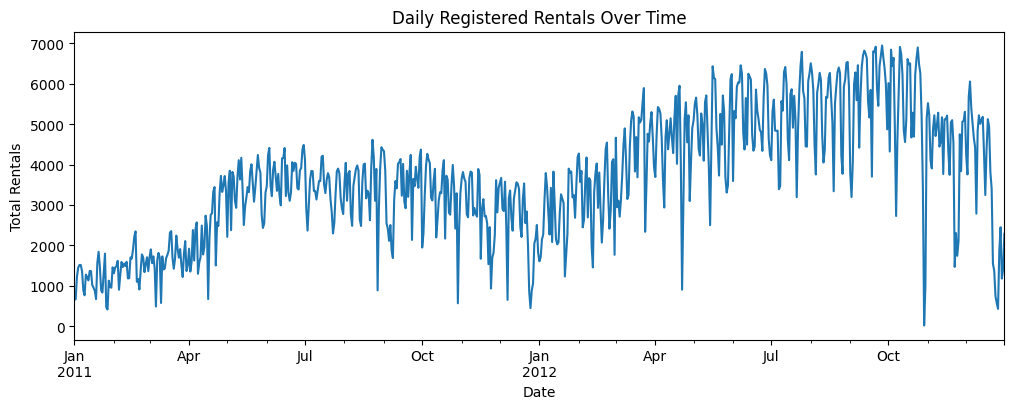

In [14]:
# Definitely an increase! Now, for the registered users.
bike_df['dteday'] = pd.to_datetime(bike_df['dteday'])
bike_df.set_index('dteday')['registered'].plot(figsize=(12, 4), 
                                               title="Daily Registered Rentals Over Time")
plt.ylabel("Total Rentals")
plt.xlabel("Date")
plt.show()

In [ ]:
# Here, it looks like there was what we call a step change in the analytical 
# lab. However, since there appears to be an increase in both groups, I'll 
# keep both. For the predictive model, however, I will have to use a weighted 
# moving average to account for the higher usage in the past year's worth of 
# data to help with predictions moving forward. I will probably also use a 
# naive and seasonal naive forecast to ensure I'm getting the most accurate 
# prediction.

In [15]:
# Before I move on, I want to run a correlation matrix to see if anything
# else in my chosen columns has a significant impact on bike usage.
numeric_cols = ['season', 'yr', 'mnth', 'holiday','weekday', 'workingday', 
                'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
                'registered', 'cnt']
corr = bike_df[numeric_cols].corr()

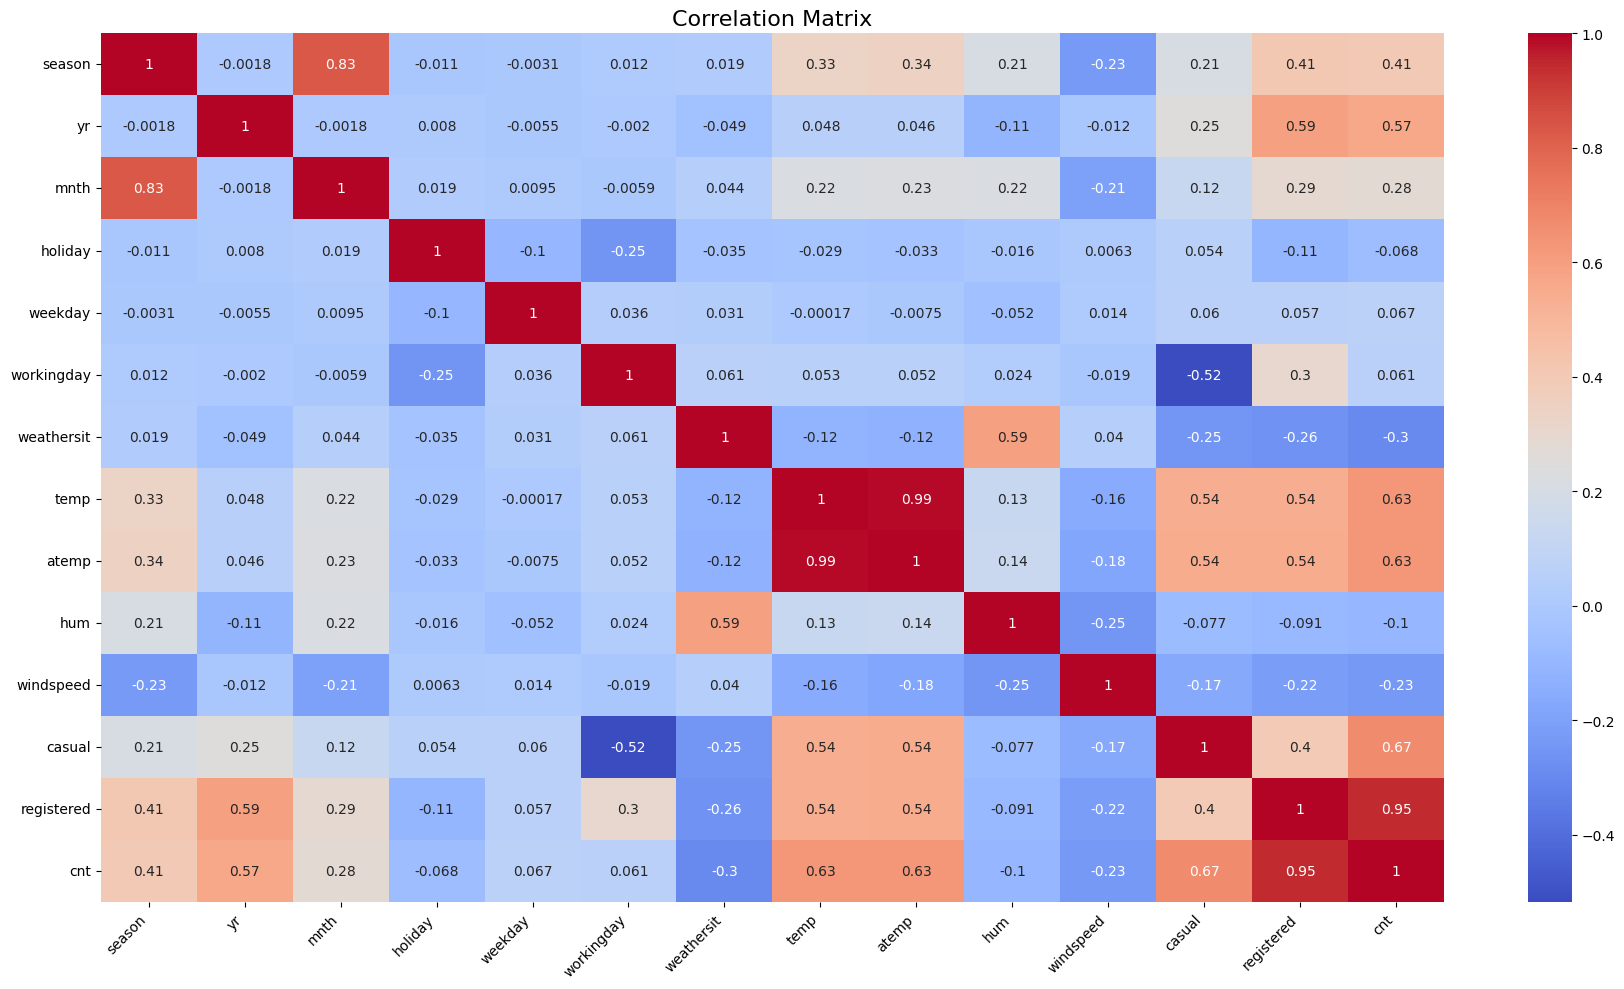

In [16]:
plt.figure(figsize=(18, 10))  # Adjust width and height here
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix", fontsize=16)
plt.yticks(rotation=0)               # Keep y-axis labels horizontal
plt.xticks(rotation=45, ha='right')  # Rotating the x-axis labels for clarity
plt.tight_layout()                   # Prevent label cutoff
plt.show()

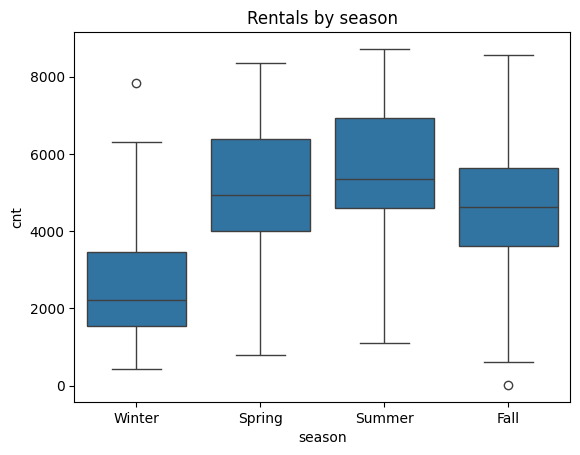

In [17]:
# This matrix tells me that there is definitely a negative correlation
# with the weather situation, but it also reveals some other factors
# that I didn't anticipate, such as the temp and atemp playing as large
# a factor as they do. The season factor, which is detailed more below,
# is not surprising. The year correlation definitely supports the earlier
# increase that we see on the time series plot.

sns.boxplot(x= 'season', y='cnt', data=bike_df)
plt.xticks([0,1,2,3], ['Winter', 'Spring', 'Summer', 'Fall'])
plt.title ("Rentals by season")
plt.show()

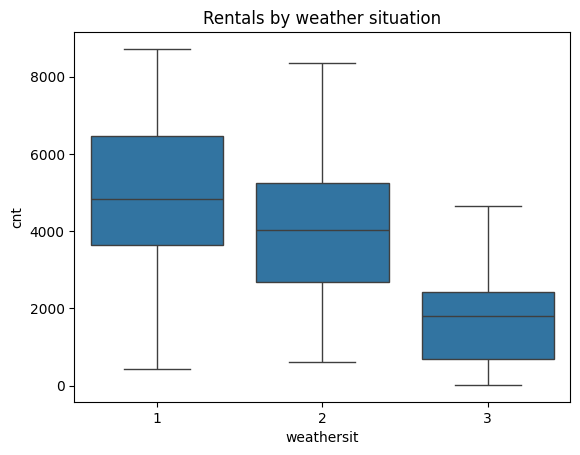

In [18]:
sns.boxplot(x= 'weathersit', y='cnt', data=bike_df)
plt.title ("Rentals by weather situation")
plt.show()

In [ ]:
# I could go so much deeper into the analysis, but I'm satisfied where
# I am with the data, so it's time to move on to the learning models.
# I learned a few things here, so I know which direction I think I should
# go, but I'll start simple and move on from there.

<font size = "4"><strong><span style = 'color:blue'> Phase 3: Machine Learning Models </span></strong></font>

In [ ]:
# For the machine learning portion, I thought about using cluster analysis,
# but I feel that the increase in overall usage that we see in the time
# series graph above would possibly make cluster analysis unusable due to 
# the increase in rentals over time, even season-over-season or month-over-
# month, which would affect the clusters a great deal. I also dismissed 
# logistic regression because my outcome variable is not categorical. I'm
# not looking for "ride" or "will not ride," but "how many will ride."
# Therefore, I will start with time series analysis, which I already have,
# and also use regression analysis to try to predict how many riders will
# rent bikes on any given upcoming day.

In [20]:
import pandas as pd
import matplotlib.pylab as plt
import statsmodels.formula.api as sm  #Again, I'll do this a lot.
from statsmodels.tsa import tsatools
from dmba import regressionSummary

In [28]:
# Since I already have the time series plot above, I won't recreate it here,
# but I do want to look at the 2012 portion for future planning, as well as
# the trends.

In [29]:
#convert dataframe column to series (name is used to label the data) I'm 
#creating the y-axis
bike_ts=pd.Series(bike_df.cnt.values, index=bike_df.dteday, name='cnt')

In [27]:
bike_ts_PastYear = bike_ts['2012']

In [30]:
#creating a data frame with additional predictors from time series
#the following command adds a constant term, a trend term, and a quadratic
#trend term

#some of my comments are either straight from the book or are just mental
#notes for myself, so I don't forget.

bike_df = tsatools.add_trend(bike_ts, trend = 'ctt')
#fit a linear regression model to the time series
bike_lm = sm.ols(formula = 'cnt ~ trend + trend_squared',
                      data=bike_df).fit()

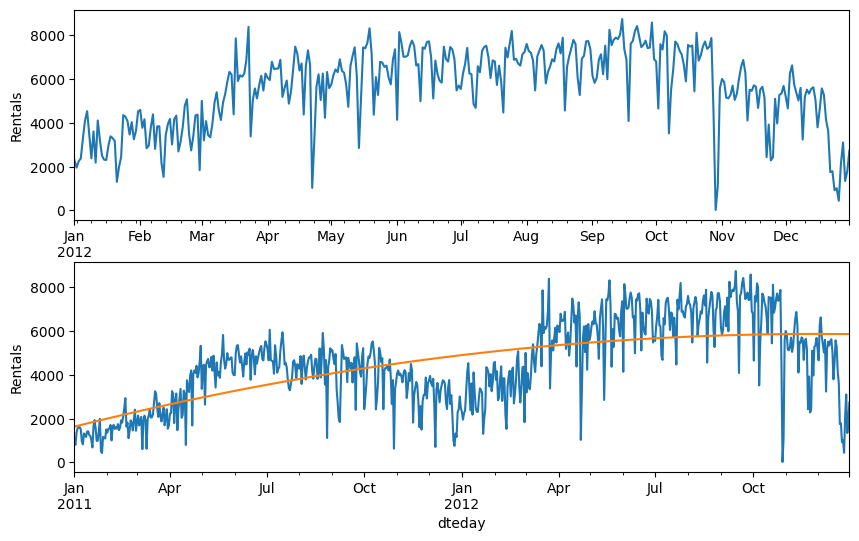

In [31]:
#shorter and longer time series
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10,6))
bike_ts_PastYear.plot(ax=axes[0])
bike_ts.plot(ax=axes[1])
for ax in axes:
    ax.set_xlabel('Time')
    ax.set_ylabel('Rentals')
bike_lm.predict(bike_df).plot(ax=axes[1])
plt.show()

In [ ]:
# I want to build my time series prediction off the 2012 graph
# because, as we see above, there has been a steady increase in
# riders overall through the past two years, so data from 2011
# will not be significant for us.

In [67]:
# Now, I'll build my prediction model from the time series and
# see what it gives me.

bike_df = pd.read_csv('day.csv')

In [69]:
# I'm going to reset to calculate the last year.
# I'm sure there's an easier way to do this, but I don't
# know it.
bike_PastYear_df=bike_df[365:]

In [70]:
bike_PastYear_df = bike_PastYear_df.drop('instant', axis=1)

Text(0, 0.5, 'Rentals')

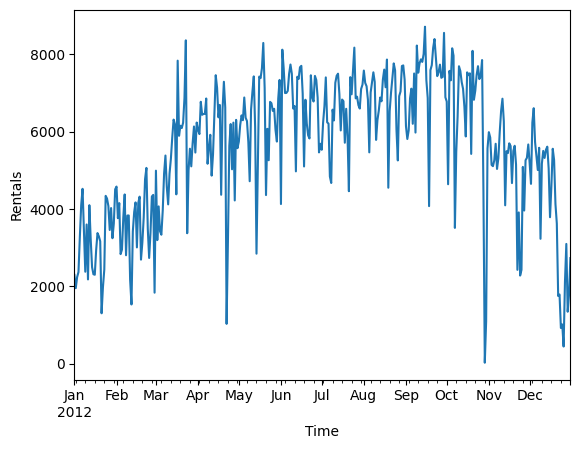

In [72]:
bike_PastYear_df['Date'] = pd.to_datetime(bike_PastYear_df.dteday, format = '%Y-%m-%d')
bike_ts=pd.Series(bike_PastYear_df.cnt.values, index=bike_PastYear_df.Date, name='cnt')
bike_ts.index = pd.DatetimeIndex(bike_ts.index, freq=bike_ts.index.inferred_freq)
ax=bike_ts.plot()
ax.set_xlabel('Time')
ax.set_ylabel('Rentals')

<font size = "3"><strong> Testing the naive and seasonal naive models</strong></font>

In [36]:
# So far, so good.
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score                  #Again, I do this a lot.
from sklearn.linear_model import LinearRegression

In [38]:
nValid = 219  #I'm following the 60% train rule here, which is where I get 219.
nTrain = len(bike_ts) - nValid

In [39]:
#Partition the data
train_ts = bike_ts[:nTrain] #training is everything up to the nTrain placeholder
valid_ts = bike_ts[nTrain:] #validation is everything after the nTrain placeholder

In [40]:
#Generate the naive and seasonal naive forecasts
naive_pred = pd.Series(train_ts[-1], index = valid_ts.index)
last_year = train_ts[-12:]

C:\Users\khrys\AppData\Local\Temp\ipykernel_31312\2198341422.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  naive_pred = pd.Series(train_ts[-1], index = valid_ts.index)


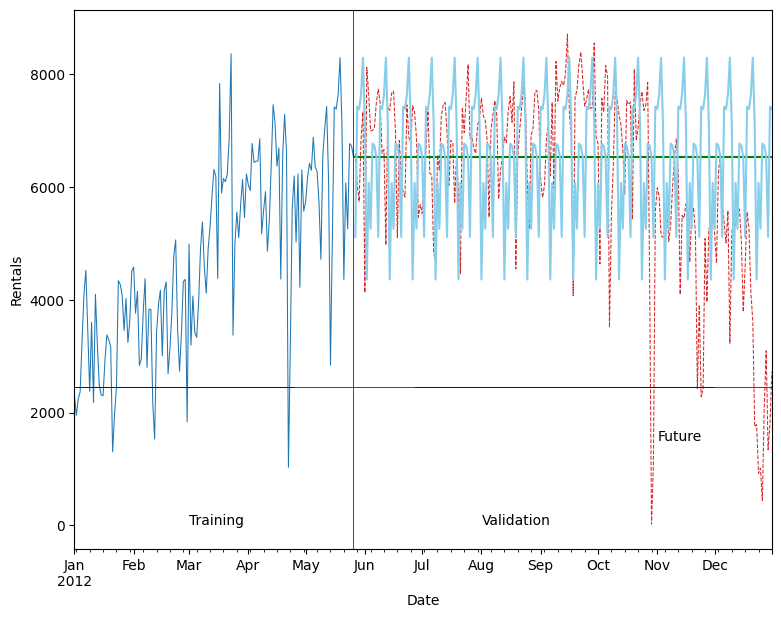

In [172]:
# I originally got an error here because my data set didn't match up
# to the index, so I had to get a little creative.

n = len(valid_ts)
seasonal_values = pd.concat([last_year] * ((n // len(last_year)) + 1))[:n].values
seasonal_pred = pd.Series(seasonal_values, index=valid_ts.index)

#Plot forecasts and actual in the training and validation sets
ax = train_ts.plot(color='C0', linewidth=0.75, figsize=(9,7))
valid_ts.plot(ax=ax, color='C3', linestyle = 'dashed', linewidth = 0.75)
ax.set_xlabel('Time')
ax.set_ylabel('Rentals')

naive_pred.plot(ax=ax, color='green')
seasonal_pred.plot(ax=ax, color='skyblue')

#Determine coordinates for drawing the arrows and lines
one_month = pd.Timedelta('31 Days')
xtrain= (min(train_ts.index), max(train_ts.index)-one_month)
xvalid= (min(valid_ts.index) + one_month, max(valid_ts.index) - one_month)
xfuture= (max(valid_ts.index) + one_month, '2012')
xtv = xtrain[1] + 0.5 * (xvalid[0] - xtrain[1])
xvf = xvalid[1] + 0.5 * (xfuture[0] - xvalid[1])

ax.add_line(plt.Line2D(xtrain, (2450, 2450), color='black', linewidth=0.5))
ax.add_line(plt.Line2D(xvalid, (2450, 2450), color='black', linewidth=0.5))
ax.add_line(plt.Line2D(xfuture, (2450, 2450), color='black', linewidth=0.5))
ax.text('2012-03', 7, 'Training')
ax.text('2012-08', 7, 'Validation')
ax.text('2012-11', 1500, 'Future')
ax.axvline(x=xtv, ymin=0, ymax=1, color='black', linewidth=0.5)
ax.axvline(x=xvf, ymin=0, ymax=1, color='black', linewidth=0.5)
plt.show()

In [173]:
# Neither the season naive nor the naive seem to be good predictors here.
# As the actual fell, both models suggested it would stay higher. Not 
# surprising, as the MAPE below demonstrates.
regressionSummary(valid_ts, naive_pred)


Regression statistics

                      Mean Error (ME) : -383.9406
       Root Mean Squared Error (RMSE) : 1698.8833
            Mean Absolute Error (MAE) : 1227.9498
          Mean Percentage Error (MPE) : -163.3618
Mean Absolute Percentage Error (MAPE) : 174.4988


In [46]:
regressionSummary(valid_ts, seasonal_pred)


Regression statistics

                      Mean Error (ME) : -408.8037
       Root Mean Squared Error (RMSE) : 2029.5861
            Mean Absolute Error (MAE) : 1580.8858
          Mean Percentage Error (MPE) : -162.8733
Mean Absolute Percentage Error (MAPE) : 179.0558


In [ ]:
# It appears that both the naive and seasonal naive models are under-
# predicting the actual values. I double checked the training values
# below and they are good, so this means that these models are not 
# what I need.

In [48]:
regressionSummary(train_ts[7:], train_ts[:-7])


Regression statistics

                      Mean Error (ME) : 158.0071
       Root Mean Squared Error (RMSE) : 1519.1246
            Mean Absolute Error (MAE) : 1108.0500
          Mean Percentage Error (MPE) : -5.1228
Mean Absolute Percentage Error (MAPE) : 28.9520


In [49]:
regressionSummary(train_ts[12:], train_ts[:-12])


Regression statistics

                      Mean Error (ME) : 313.3630
       Root Mean Squared Error (RMSE) : 1588.8253
            Mean Absolute Error (MAE) : 1195.4815
          Mean Percentage Error (MPE) : -2.0703
Mean Absolute Percentage Error (MAPE) : 29.6029


<font size = "3"><strong> Testing the moving average models</strong></font>

In [174]:
# Again, I only want to use the 2012 data, as there has been
# an overall increase in rentals which I think could 
# affect the data adversely if I included 2011.
bike_PastYear_df['dteday'] = pd.date_range(start = '2012-01-01', 
                                           periods = len(bike_PastYear_df), freq = 'D')
bike_PastYear_df.set_index('dteday', inplace=True)
bike_PastYear_df.index.freq = 'D' #Explicitly setting the frequency
bike_series = bike_PastYear_df['cnt']

In [79]:
def calculate_metrics(actual, forecast):
    mae=mean_absolute_error(actual, forecast)
    mse=mean_squared_error(actual, forecast)
    rmse=np.sqrt(mse)
    mape=np.mean(np.abs((actual-forecast)/actual))*100
    return mape, mae, mse, rmse

In [175]:
# Setting up for our forecasts. I want to predict a 14-day period
# just to see how accurate the models can be going forward.

future_dates = pd.date_range(start=bike_series.index[-1] + pd.offsets.MonthBegin(), 
                             periods=14, freq="D")

In [177]:
# I'm starting with a two-day moving average because I feel like
# weather patterns tend to grow and lessen slowly and each day
# could affect the next. This is only a perceptual thing.

#2-day moving average
moving_avg_2=bike_series.rolling(window=2).mean()

moving_avg_2_future = []
extended_series = bike_series.copy()
for _ in range(14):
    next_value = extended_series[-2:].mean()
    moving_avg_2_future.append(next_value)
    extended_series = pd.concat([extended_series, 
                                 pd.Series([next_value],
                                           index=[extended_series.index[-1]+pd.offsets.MonthBegin()])])

In [179]:
for i, prediction in enumerate(moving_avg_2_future, 1):
    print(f"Day {i} prediction: {prediction: .2f}")

# The numbers are somewhat level, which leads me to believe
# that this model might be good for predicting the next day
# or two, but not the next one to two weeks.

Day 1 prediction:  2262.50
Day 2 prediction:  2495.75
Day 3 prediction:  2379.12
Day 4 prediction:  2437.44
Day 5 prediction:  2408.28
Day 6 prediction:  2422.86
Day 7 prediction:  2415.57
Day 8 prediction:  2419.21
Day 9 prediction:  2417.39
Day 10 prediction:  2418.30
Day 11 prediction:  2417.85
Day 12 prediction:  2418.08
Day 13 prediction:  2417.96
Day 14 prediction:  2418.02


In [180]:
#7-day weighted moving average without lambda function
weights=np.array([0.1,0.1,0.1,0.2, 0.2, 0.2, 0.3])  #This is the weighting method.

# I tried several different weighting methods, but none
# gave consistent predictions. In the future, I will look
# at which day of the week I'm starting this series on
# and weight based on the weekday. This might account for
# a seasonal trend.

def weighted_moving_average(series, window, weights):
    result = []
    for i in range(len(series)):
        if i+1<window:
            result.append(np.nan)
        else:
            weighted_sum = 0
            for j in range(window):
                weighted_sum+=series.iloc[i-j]*weights[j]
            result.append(weighted_sum)
    return pd.Series(result, index=series.index)

weighted_moving_avg_7 = weighted_moving_average(bike_series, 7, weights)

weighted_moving_avg_7_future = []
extended_series = bike_series.copy()
for _ in range(14):
    if len(extended_series)<14:
        break
    last_values = extended_series.iloc[-7:]
    next_value = np.dot(last_values[::-1],weights)
    extended_series = pd.concat([extended_series, pd.Series([next_value])], ignore_index=True)
    weighted_moving_avg_7_future.append(next_value)

In [181]:
for i, prediction in enumerate(weighted_moving_avg_7_future, 1):
    print(f"Day {i} prediction: {prediction: .2f}")

Day 1 prediction:  2020.50
Day 2 prediction:  2096.85
Day 3 prediction:  2565.24
Day 4 prediction:  2769.96
Day 5 prediction:  2454.60
Day 6 prediction:  2687.05
Day 7 prediction:  2946.38
Day 8 prediction:  2901.36
Day 9 prediction:  3040.49
Day 10 prediction:  3240.72
Day 11 prediction:  3366.85
Day 12 prediction:  3408.15
Day 13 prediction:  3585.33
Day 14 prediction:  3756.46


In [167]:
#Exponential smoothing with smoothing constant 0.3
exp_smoothing_0_3_model = SimpleExpSmoothing(bike_series).fit(smoothing_level=0.3,
                                                              optimized=False)
exp_smoothing_0_3 = exp_smoothing_0_3_model.fittedvalues
exp_smoothing_0_3_future = exp_smoothing_0_3_model.forecast(14)

In [91]:
# Honestly, the smoothing feature isn't helpful at all
# for what I want to achieve. I tried it to see what data
# it could give me.

for i, prediction in enumerate(exp_smoothing_0_3_future, 1):
    print(f"Day {i} exponential smoothing prediction: {prediction: .2f}")

Day 1 exponential smoothing prediction:  2121.99
Day 2 exponential smoothing prediction:  2121.99
Day 3 exponential smoothing prediction:  2121.99
Day 4 exponential smoothing prediction:  2121.99
Day 5 exponential smoothing prediction:  2121.99
Day 6 exponential smoothing prediction:  2121.99
Day 7 exponential smoothing prediction:  2121.99
Day 8 exponential smoothing prediction:  2121.99
Day 9 exponential smoothing prediction:  2121.99
Day 10 exponential smoothing prediction:  2121.99
Day 11 exponential smoothing prediction:  2121.99
Day 12 exponential smoothing prediction:  2121.99
Day 13 exponential smoothing prediction:  2121.99
Day 14 exponential smoothing prediction:  2121.99


In [92]:
#Exponential smoothing with smoothing constant 0.3 using Holt smoothing instead of simple
from statsmodels.tsa.holtwinters import Holt
exp_smoothing_0_3_model = Holt(bike_series, initialization_method='estimated').fit(smoothing_level=0.3)
exp_smoothing_0_3 = exp_smoothing_0_3_model.fittedvalues
exp_smoothing_0_3_future = exp_smoothing_0_3_model.forecast(14)

In [182]:
# Again, not useful for what I am wanting to achieve.

for i, prediction in enumerate(exp_smoothing_0_3_future, 1):
    print(f"Day {i} exponential smoothing prediction: {prediction: .2f}")

Day 1 exponential smoothing prediction:  2121.99
Day 2 exponential smoothing prediction:  2121.99
Day 3 exponential smoothing prediction:  2121.99
Day 4 exponential smoothing prediction:  2121.99
Day 5 exponential smoothing prediction:  2121.99
Day 6 exponential smoothing prediction:  2121.99
Day 7 exponential smoothing prediction:  2121.99
Day 8 exponential smoothing prediction:  2121.99
Day 9 exponential smoothing prediction:  2121.99
Day 10 exponential smoothing prediction:  2121.99
Day 11 exponential smoothing prediction:  2121.99
Day 12 exponential smoothing prediction:  2121.99
Day 13 exponential smoothing prediction:  2121.99
Day 14 exponential smoothing prediction:  2121.99


In [183]:
# But I do keep trying. At least I'm learning a little bit
# about the coding of these models.

exp_smoothing_0_8_model = Holt(bike_series, initialization_method='estimated').fit(smoothing_level=0.8)
exp_smoothing_0_8 = exp_smoothing_0_8_model.fittedvalues
exp_smoothing_0_8_future = exp_smoothing_0_8_model.forecast(14)

In [184]:
for i, prediction in enumerate(exp_smoothing_0_8_future, 1):
    print(f"Day {i} exponential smoothing prediction: {prediction: .2f}")

Day 1 exponential smoothing prediction:  2537.62
Day 2 exponential smoothing prediction:  2538.79
Day 3 exponential smoothing prediction:  2539.96
Day 4 exponential smoothing prediction:  2541.12
Day 5 exponential smoothing prediction:  2542.29
Day 6 exponential smoothing prediction:  2543.46
Day 7 exponential smoothing prediction:  2544.63
Day 8 exponential smoothing prediction:  2545.79
Day 9 exponential smoothing prediction:  2546.96
Day 10 exponential smoothing prediction:  2548.13
Day 11 exponential smoothing prediction:  2549.29
Day 12 exponential smoothing prediction:  2550.46
Day 13 exponential smoothing prediction:  2551.63
Day 14 exponential smoothing prediction:  2552.79


In [185]:
#Simple linear regression
days = np.arange(len(bike_series)).reshape(-1,1)
reg_model = LinearRegression().fit(days, bike_series)
future_days = np.arange(len(bike_series), len(bike_series) +14).reshape(-1,1)
linear_regression = reg_model.predict(days)
linear_regression_future = reg_model.predict(future_days)

In [186]:
for i, prediction in enumerate(linear_regression_future, 1):
    print(f"Day {i} linear regression prediction: {prediction: .2f}")

#I'm not worried about the numbers below because I believe that this
#simple linear regression is overfitting. When I do the larger regression
#below, I believe we'll see some more accurate numbers.

Day 1 linear regression prediction:  6405.39
Day 2 linear regression prediction:  6409.78
Day 3 linear regression prediction:  6414.17
Day 4 linear regression prediction:  6418.56
Day 5 linear regression prediction:  6422.95
Day 6 linear regression prediction:  6427.34
Day 7 linear regression prediction:  6431.73
Day 8 linear regression prediction:  6436.12
Day 9 linear regression prediction:  6440.51
Day 10 linear regression prediction:  6444.90
Day 11 linear regression prediction:  6449.29
Day 12 linear regression prediction:  6453.68
Day 13 linear regression prediction:  6458.07
Day 14 linear regression prediction:  6462.46


In [187]:
#Calculate error metrics for each method
metrics = {
    '2-Day Moving Average': calculate_metrics(bike_series[1:], moving_avg_2.dropna()),
    '7-Day Weighted Moving Average': calculate_metrics(bike_series[6:], 
                                                       weighted_moving_avg_7.dropna()),
    'Exponential Smoothing 0.3': calculate_metrics(bike_series[1:], exp_smoothing_0_3[1:]),
    'Exponential Smoothing 0.8': calculate_metrics(bike_series[1:], exp_smoothing_0_8[1:]),
    'Linear Regression': calculate_metrics(bike_series, linear_regression)}

In [102]:
metrics_df = pd.DataFrame(metrics, index=['MAPE', 'MAE', 'MSE', 'RMSE'])
metrics_df

,2-Day Moving Average,7-Day Weighted Moving Average,Exponential Smoothing 0.3,Exponential Smoothing 0.8,Linear Regression
MAPE,37.987174,1.327908e+02,1.031063e+02,8.341607e+01,1.160811e+02
MAE,436.017808,1.270293e+03,8.264617e+02,8.422499e+02,1.406838e+03
MSE,389397.455479,2.739774e+06,1.308817e+06,1.429600e+06,2.975514e+06
RMSE,624.017192,1.655226e+03,1.144035e+03,1.195659e+03,1.724968e+03


In [188]:
# If I were to choose one of these models, I would go with the two-
# day moving average. Its 38% MAPE is still somewhat high, but is
# low enough to give a controller a general idea of where to 
# allocate resources and it does so much better than the other 
# three models.

<font size = "3"><strong> Testing the multiple linear regression model</strong></font>

In [194]:
# Just to be sure, I'm importing again because there 
# was a lot above this and I don't want to miss anything
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge, LassoCV, BayesianRidge
import statsmodels.formula.api as sm
import matplotlib.pylab as plt

# I'm selecting the models I want to run and the 
# model evaluation methods.
from dmba import regressionSummary, exhaustive_search
from dmba import backward_elimination, forward_selection, stepwise_selection
from dmba import adjusted_r2_score, AIC_score, BIC_score

In [193]:
# Just double checking everything here.
print(bike_df.columns)

Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered', 'cnt'],
      dtype='object')


In [196]:
# Starting with all possible predictors.

predictors = ['season', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit',
              'temp', 'atemp', 'hum', 'windspeed']
outcome = 'cnt'

In [197]:
#partition the data
x=pd.get_dummies(bike_df[predictors])
y=bike_df[outcome]
train_x, valid_x, train_y, valid_y = train_test_split(x, y, test_size = 0.4, random_state=1)

In [199]:
bike_lm=LinearRegression()
bike_lm.fit(train_x, train_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [201]:
#print coefficients
print(pd.DataFrame({'Predictor' : x.columns, 'coefficient' : bike_lm.coef_}))

# Based on this below, I can already see that I'll 
# probably be dropping weekday, workingday, mnth,
# and maybe holiday. Their coefficients just don't
# indicate a high level of significance.

    Predictor  coefficient
0      season   528.286593
1        mnth   -33.110271
2     holiday  -248.770934
3     weekday   101.909042
4  workingday   103.536858
5  weathersit  -483.467082
6        temp  1407.012755
7       atemp  4282.351361
8         hum -2565.540451
9   windspeed -2847.803000


In [203]:
#print performance measures
regressionSummary(train_y, bike_lm.predict(train_x))

# The train MAPE looks good.


Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 1359.3322
            Mean Absolute Error (MAE) : 1152.3738
          Mean Percentage Error (MPE) : -14.8925
Mean Absolute Percentage Error (MAPE) : 33.6671


In [204]:
# Making predictions on a new set
bike_lm_pred = bike_lm.predict(valid_x)

In [205]:
result = pd.DataFrame({'Predicted': bike_lm_pred, 'Actual': valid_y,
                       'Residual': valid_y-bike_lm_pred})

In [206]:
print(result.head(20))

       Predicted  Actual     Residual
404  3146.397191    3830   683.602809
726  1487.652276    2114   626.347724
159  6055.254137    3915 -2140.254137
422  3366.745689    4322   955.254311
512  4880.509489    6591  1710.490511
241  5983.612396    5204  -779.612396
698  4851.711252    5323   471.288748
247  4322.600278    3351  -971.600278
355  3174.078167    3068  -106.078167
528  4085.424730    4972   886.575270
120  3377.393874    3351   -26.393874
69   2653.101364    1977  -676.101364
8    1715.680381     822  -893.680381
364  3558.805641    2485 -1073.805641
524  5917.719690    7736  1818.280310
368  2166.652279    2368   201.347721
180  6636.878427    5515 -1121.878427
495  4582.116005    6572  1989.883995
259  4445.724248    4511    65.275752
506  3804.834806    4359   554.165194


In [208]:
regressionSummary(valid_y, bike_lm_pred)

# So, it looks like the predictions of the 
# original dataset are not so great, with a
# MAPE of 78%! Being off by 78% is not good.
# The ME and MPE indicate that the current
# model is underpredicting.


Regression statistics

                      Mean Error (ME) : -61.5706
       Root Mean Squared Error (RMSE) : 1301.4641
            Mean Absolute Error (MAE) : 1098.1904
          Mean Percentage Error (MPE) : -60.7836
Mean Absolute Percentage Error (MAPE) : 78.4148


In [209]:
all_residuals = valid_y-bike_lm_pred

In [211]:
# Finding the range of 75% of our residuals. I played
# around with the numbers before finally getting 1520.

print(len(all_residuals[(all_residuals>-1520) & (all_residuals<1520)])/len(all_residuals))

0.7508532423208191


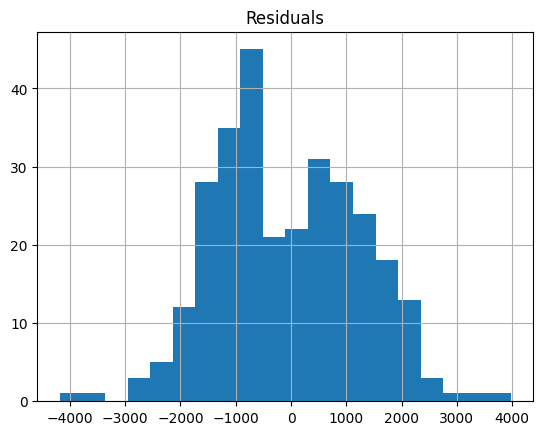

In [213]:
pd.DataFrame({'Residuals': all_residuals}).hist(bins=20)
plt.show()

# I'm trying not to use my statistical side too much, but
# the twin peaks in the residual histogram indicates some
# bimodal error behavior, maybe indicating some collinearity?

In [214]:
# Performing an exhaustive search to reduce variables
def train_model(variables):
    model =  LinearRegression()
    model.fit(train_x[list(variables)], train_y)
    return model

In [215]:
def score_model(model, variables):
    pred_y = model.predict(train_x[list(variables)])
    return -adjusted_r2_score(train_y, pred_y, model)

In [216]:
allVariables = train_x.columns
results = exhaustive_search(allVariables, train_model, score_model)

In [219]:
data=[]
for result in results:
    model=result['model']
    variables=list(result['variables'])
    AIC = AIC_score(train_y, model.predict(train_x[variables]), model)
    d= {'n': result['n'], 'r2adj': -result['score'], 'AIC':AIC}
    d.update({var: var in result['variables'] for var in allVariables})
    data.append(d)
pd.DataFrame(data, columns=('n', 'r2adj', 'AIC') + tuple(sorted(allVariables)))

# Model 5 (n 6) appears to be the best
# It suggests dropping holiday, mnth, temp, and workingday.
# Not exactly what I though above, but close. I assume that 
# it suggests dropping temp due to the collinearity with atemp.

,n,r2adj,AIC,atemp,holiday,hum,mnth,season,temp,weathersit,weekday,windspeed,workingday
0,1,0.333198,7685.636528,True,False,False,False,False,False,False,False,False,False
1,2,0.394144,7644.648002,True,False,False,False,False,False,True,False,False,False
2,3,0.446531,7606.028823,True,False,True,False,True,False,False,False,False,False
3,4,0.461252,7595.210260,True,False,True,False,True,False,False,False,True,False
4,5,0.472384,7587.052463,True,False,True,False,True,False,False,True,True,False
5,6,0.480198,7581.502375,True,False,True,False,True,False,True,True,True,False
6,7,0.480076,7582.587744,True,False,True,True,True,False,True,True,True,False
7,8,0.479824,7583.780022,True,False,True,True,True,False,True,True,True,True
8,9,0.478996,7585.454797,True,True,True,True,True,False,True,True,True,True
9,10,0.478187,7587.110139,True,True,True,True,True,True,True,True,True,True


In [220]:
# Backward selection
def train_model(variables):
    model =  LinearRegression()
    model.fit(train_x[list(variables)], train_y)
    return model

In [221]:
def score_model(model, variables):
    return AIC_score(train_y, model.predict(train_x[variables]), model)

In [222]:
allVariables = train_x.columns
best_model, best_variables = backward_elimination(allVariables, train_model,
                                                  score_model, verbose=True)

Variables: season, mnth, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed
Start: score=7587.11
Step: score=7585.45, remove temp
Step: score=7583.78, remove holiday
Step: score=7582.59, remove workingday
Step: score=7581.50, remove mnth
Step: score=7581.50, remove None


In [224]:
print(best_variables)
# The backward selection model agrees with the exhaustive search.

['season', 'weekday', 'weathersit', 'atemp', 'hum', 'windspeed']


In [129]:
regressionSummary(valid_y, best_model.predict(valid_x[best_variables]))
# Even the best variables model here isn't great


Regression statistics

                      Mean Error (ME) : -60.0918
       Root Mean Squared Error (RMSE) : 1311.7287
            Mean Absolute Error (MAE) : 1108.8584
          Mean Percentage Error (MPE) : -60.7962
Mean Absolute Percentage Error (MAPE) : 78.6970


In [226]:
# Forward selection
def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(train_x[variables], train_y)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(train_y, [train_y.mean()] * len(train_y), model, df=1)
    return AIC_score(train_y, model.predict(train_x[variables]), model)

best_model, best_variables = forward_selection(train_x.columns, train_model, 
                                               score_model, verbose=True)
print(best_variables)

# I am definitely sensing a pattern in the selection of variables.

Variables: season, mnth, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed
Start: score=7862.14, constant
Step: score=7685.64, add atemp
Step: score=7644.65, add weathersit
Step: score=7607.69, add season
Step: score=7597.10, add weekday
Step: score=7588.42, add hum
Step: score=7581.50, add windspeed
Step: score=7581.50, add None
['atemp', 'weathersit', 'season', 'weekday', 'hum', 'windspeed']


In [227]:
# Stepwise regression
best_model, best_variables = stepwise_selection(train_x.columns, train_model, 
                                                score_model, verbose=True)
print(best_variables)

Variables: season, mnth, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed
Start: score=7862.14, constant
Step: score=7685.64, add atemp
Step: score=7644.65, add weathersit
Step: score=7607.69, add season
Step: score=7597.10, add weekday
Step: score=7588.42, add hum
Step: score=7581.50, add windspeed
Step: score=7581.50, unchanged None
['atemp', 'weathersit', 'season', 'weekday', 'hum', 'windspeed']


In [228]:
# Since the models all seem to agree that there are six variables that
# are important, I'm going to eliminate the others and see what happens.
predictors = ['season','weekday','weathersit','atemp', 'hum', 'windspeed']
outcome = 'cnt'

In [229]:
#partition the data
x=pd.get_dummies(bike_df[predictors])
y=bike_df[outcome]
train_x, valid_x, train_y, valid_y = train_test_split(x, y, test_size = 0.4, random_state=1)

In [230]:
bike_lm=LinearRegression()
bike_lm.fit(train_x, train_y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [231]:
#print coefficients
print(pd.DataFrame({'Predictor' : x.columns, 'coefficient' : bike_lm.coef_}))

# Based on the below, I would have probably eliminated
# weekday, but the data doesn't lie!

    Predictor  coefficient
0      season   442.521521
1     weekday   108.647640
2  weathersit  -459.290304
3       atemp  5940.776158
4         hum -2652.115612
5   windspeed -2742.295552


In [232]:
#print performance measures
regressionSummary(train_y, bike_lm.predict(train_x))

# This training set looks good.


Regression statistics

                      Mean Error (ME) : -0.0000
       Root Mean Squared Error (RMSE) : 1363.0494
            Mean Absolute Error (MAE) : 1154.7090
          Mean Percentage Error (MPE) : -15.1193
Mean Absolute Percentage Error (MAPE) : 33.9605


In [233]:
# Making predictions on a new set
bike_lm_pred = bike_lm.predict(valid_x)

In [234]:
result = pd.DataFrame({'Predicted': bike_lm_pred, 'Actual': valid_y,
                       'Residual': valid_y-bike_lm_pred})

In [235]:
print(result.head(20))

       Predicted  Actual     Residual
404  3059.873223    3830   770.126777
726  1721.636609    2114   392.363391
159  6091.807232    3915 -2176.807232
422  3290.087163    4322  1031.912837
512  4905.963185    6591  1685.036815
241  5929.976774    5204  -725.976774
698  4836.251115    5323   486.748885
247  4663.357157    3351 -1312.357157
355  3459.856635    3068  -391.856635
528  4045.610541    4972   926.389459
120  3424.811031    3351   -73.811031
69   2625.977053    1977  -648.977053
8    1637.821217     822  -815.821217
364  3966.784856    2485 -1481.784856
524  5907.288535    7736  1828.711465
368  2061.269486    2368   306.730514
180  6536.000689    5515 -1021.000689
495  4564.929791    6572  2007.070209
259  4586.810686    4511   -75.810686
506  3753.023302    4359   605.976698


In [237]:
regressionSummary(valid_y, bike_lm_pred)
# I still have a high MAPE, so still not great.


Regression statistics

                      Mean Error (ME) : -60.0918
       Root Mean Squared Error (RMSE) : 1311.7287
            Mean Absolute Error (MAE) : 1108.8584
          Mean Percentage Error (MPE) : -60.7962
Mean Absolute Percentage Error (MAPE) : 78.6970


In [238]:
all_residuals=valid_y-bike_lm_pred

In [239]:
print(len(all_residuals[(all_residuals>-1515)&(all_residuals<1515)])/len(all_residuals))

0.7508532423208191


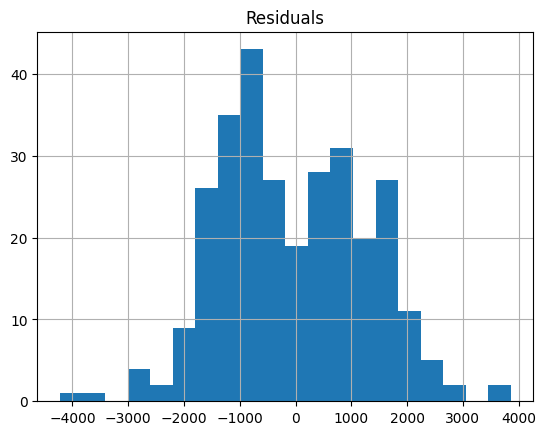

In [240]:
pd.DataFrame({'Residuals': all_residuals}).hist(bins=20)
plt.show()

In [242]:
# Running Lasso regression just to see if more variables
# can be excluded.
lasso = Lasso(alpha =1)
lasso.fit(train_x, train_y)
regressionSummary(valid_y, lasso.predict(valid_x))

# Based on the numbers, however, it looks like no
# further variables can be excluded


Regression statistics

                      Mean Error (ME) : -58.2276
       Root Mean Squared Error (RMSE) : 1312.5183
            Mean Absolute Error (MAE) : 1111.0403
          Mean Percentage Error (MPE) : -61.4284
Mean Absolute Percentage Error (MAPE) : 79.3599


In [156]:
lasso_cv=LassoCV(cv=5)
lasso_cv.fit(train_x, train_y)
regressionSummary(valid_y, lasso_cv.predict(valid_x))
print("Lasso-CV chosen regularlization: ", lasso_cv.alpha_)
print(lasso_cv.coef_)


Regression statistics

                      Mean Error (ME) : -58.5925
       Root Mean Squared Error (RMSE) : 1312.3364
            Mean Absolute Error (MAE) : 1110.6128
          Mean Percentage Error (MPE) : -61.3037
Mean Absolute Percentage Error (MAPE) : 79.2292
Lasso-CV chosen regularlization:  0.803508162882342
[  443.84447271   108.75355997  -478.14046003  5898.34103217
 -2539.79055007 -2564.00930505]


In [244]:
#Running ridge to check for any more correlations.
ridge = Ridge(alpha =1)
ridge.fit(train_x, train_y)
regressionSummary(valid_y, ridge.predict(valid_x))

# This still indicates that all six variables are 
# significant.


Regression statistics

                      Mean Error (ME) : -59.1262
       Root Mean Squared Error (RMSE) : 1328.6567
            Mean Absolute Error (MAE) : 1130.2500
          Mean Percentage Error (MPE) : -64.1837
Mean Absolute Percentage Error (MAPE) : 82.1045


In [158]:
bayesianridge = BayesianRidge()
bayesianridge.fit(train_x, train_y)
regressionSummary(valid_y, bayesianridge.predict(valid_x))
alpha = bayesianridge.lambda_/bayesianridge.alpha_
print('Bayesian ridge chosen regularlization: ', alpha)


Regression statistics

                      Mean Error (ME) : -59.1233
       Root Mean Squared Error (RMSE) : 1314.9626
            Mean Absolute Error (MAE) : 1114.3855
          Mean Percentage Error (MPE) : -61.7853
Mean Absolute Percentage Error (MAPE) : 79.7006
Bayesian ridge chosen regularlization:  0.240216132960583


In [250]:
import statsmodels.api as sm

# Define predictors and response
X = bike_df[['atemp', 'hum', 'season', 'weathersit', 'weekday', 'windspeed']]
y = bike_df['cnt']

# Add constant for intercept
X = sm.add_constant(X)

# Fit the model
bike6 = sm.OLS(y, X).fit()

# View summary
print(bike6.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.523
Model:                            OLS   Adj. R-squared:                  0.519
Method:                 Least Squares   F-statistic:                     132.5
Date:                Sat, 09 Aug 2025   Prob (F-statistic):          6.09e-113
Time:                        18:34:26   Log-Likelihood:                -6298.9
No. Observations:                 731   AIC:                         1.261e+04
Df Residuals:                     724   BIC:                         1.264e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2962.7585    341.281      8.681      0.0

In [251]:
# I'd like to see a higher R-squared value, but there are a lot
# variables in place, so 52% is pretty good, given the complexity
# of the problem. There appears to be a significant correlation with
# atemp (what the temperature feels like outside), suggesting that
# when it's warm, people ride more, but a strong negative 
# correlation with humidity and strong winds.

# If I were the planner, I would use a combination of the two-
# day forecast, which seems to be the strongest model, and those
# those three predictors for the upcoming days. Using that setup, 
# I believe, gives me the best chance to place my resources.